In [1]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import numpy as np
import os
import glob
import awkward as ak
import boost_histogram as bh
import mplhep
from copy import deepcopy
# !pip install pyarrow
# !pip install "pyarrow<21" --break-system-packages

In [2]:
runs_F222 = [7733, 8712]
runs_F223 = [8713, 9188]

runs_F231 = [10555, 11470]
runs_F232 = [11470, 11703]

runs_F241 = [14399, 15026]
runs_tungsten = [15030, 15594]
runs_F242 = [15652, 15820]
runs_caloNu = [15821, 16924]
runs_F243 = [16928, 17230]

runs_2022 = [8025, 9188]
runs_2023 = [10604, 11703]

runs_2024_preCaloNu = [14399, 15821]
runs_2024_CaloNu = [15821, 16924]
runs_2024_afterCaloNu = [16928, 17230]

In [3]:
lumi_2024_noCaloNu = 50.10
lumi_2024_CaloNu = 70.03

In [4]:
def parse_grl_csv(file_path):
    grl_df = pd.read_csv(file_path)
    return grl_df

grl_2022_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2022_physics.csv")
grl_2023_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2023_physics.csv")
grl_2024_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2024_physics.csv")
grl_df = pd.concat([grl_2022_df, grl_2023_df, grl_2024_df], ignore_index=True)

In [5]:
data_files = glob.glob("AnalysisZipFramework/submission/analysis_output-moreHists/*.root")

calonu_data_files = []
non_caloNu_2024_data_files = []

for file in data_files:
    run_num = int(os.path.basename(file).split('.')[0])

    if runs_caloNu[0] <= run_num <= runs_caloNu[1]:
        calonu_data_files.append(f"{file}")
    if runs_2024_preCaloNu[0] <= run_num <= runs_2024_preCaloNu[1]:
        non_caloNu_2024_data_files.append(f"{file}")
    if runs_2024_afterCaloNu[0] <= run_num <= runs_2024_afterCaloNu[1]:
        non_caloNu_2024_data_files.append(f"{file}")
    

In [6]:
mc_2024_noCaloNu = uproot.open("build/MC_no_truth_cuts_fixed_ENFB8/2024_noCaloNu.bck.root")
mc_2024_CaloNu = uproot.open("build/MC_no_truth_cuts_fixed_ENFB8/2024_CaloNu.bck.root")

In [7]:
# for k in mc_2024_CaloNu['histograms'].keys():
#     print(k)

In [8]:
hists_to_plot = [
    "nClusters0_preLongTracks;1",
    "nClusters1_preLongTracks;1",
    "nClusters2_preLongTracks;1",
    "nClusters3_preLongTracks;1",
    "SpacePoints_preLongTracks;1",
    "TrackSegments_preLongTracks;1",
    "nClusters0;1",
    "nClusters1;1",
    "nClusters2;1",
    "nClusters3;1",
    "SpacePoints;1",
    "TrackSegments;1"
]

In [9]:
histograms_noCaloNu = {}
for file in tqdm.tqdm(non_caloNu_2024_data_files):
    with uproot.open(file) as root_file:

        try:
            histograms_group = root_file['histograms']
        except KeyError:
            print(f"Warning: 'histograms' key not found in {file}. Skipping this file.")
            continue

        for hist_name, hist in root_file['histograms'].items():
            if hist_name in hists_to_plot:
                if hist_name not in histograms_noCaloNu:
                    histograms_noCaloNu[hist_name] = hist.to_boost()
                else:
                    histograms_noCaloNu[hist_name] += hist.to_boost()

histograms_CaloNu = {}
for file in tqdm.tqdm(calonu_data_files):

    with uproot.open(file) as root_file:
        try:
            histograms_group = root_file['histograms']
        except KeyError:
            print(f"Warning: 'histograms' key not found in {file}. Skipping this file.")
            continue

        for hist_name, hist in root_file['histograms'].items():
            if hist_name in hists_to_plot:
                if hist_name not in histograms_CaloNu:
                    histograms_CaloNu[hist_name] = hist.to_boost()
                else:
                    histograms_CaloNu[hist_name] += hist.to_boost()

 68%|██████▊   | 89/130 [00:20<00:08,  4.83it/s]

100%|██████████| 130/130 [00:29<00:00,  4.48it/s]


In [10]:
histograms_CaloNu.keys()

dict_keys(['nClusters0_preLongTracks;1', 'nClusters1_preLongTracks;1', 'nClusters2_preLongTracks;1', 'nClusters3_preLongTracks;1', 'SpacePoints_preLongTracks;1', 'TrackSegments_preLongTracks;1', 'nClusters0;1', 'nClusters1;1', 'nClusters2;1', 'nClusters3;1', 'SpacePoints;1', 'TrackSegments;1'])

In [11]:
histograms_noCaloNu.keys()

dict_keys(['nClusters0_preLongTracks;1', 'nClusters1_preLongTracks;1', 'nClusters2_preLongTracks;1', 'nClusters3_preLongTracks;1', 'SpacePoints_preLongTracks;1', 'TrackSegments_preLongTracks;1', 'nClusters0;1', 'nClusters1;1', 'nClusters2;1', 'nClusters3;1', 'SpacePoints;1', 'TrackSegments;1'])

In [12]:
def sum_histograms(histograms):
    summed_hist = None
    for hist in tqdm.tqdm(histograms):
        if summed_hist is None:
            summed_hist = hist.to_boost()
        else:
            summed_hist += hist.to_boost()
    return summed_hist

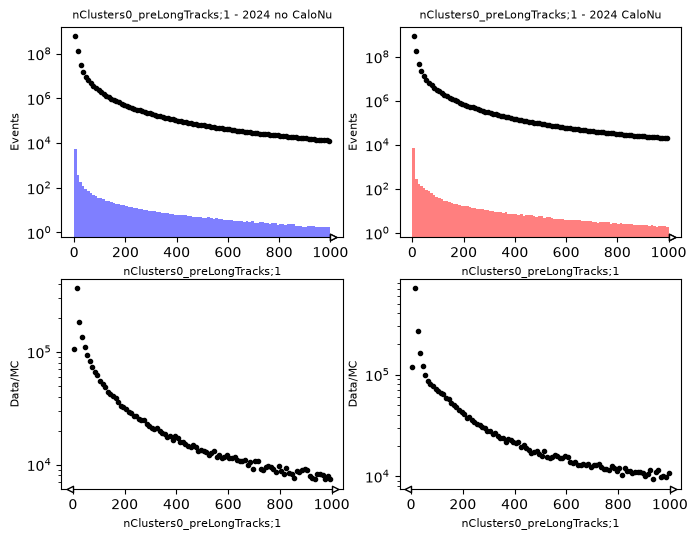

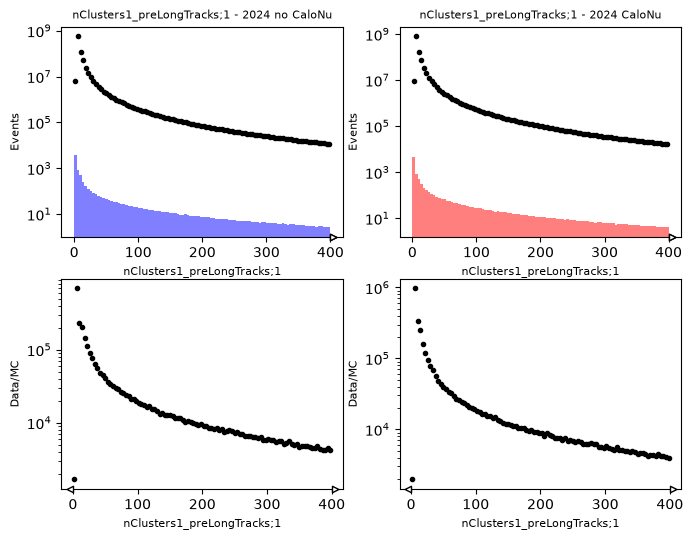

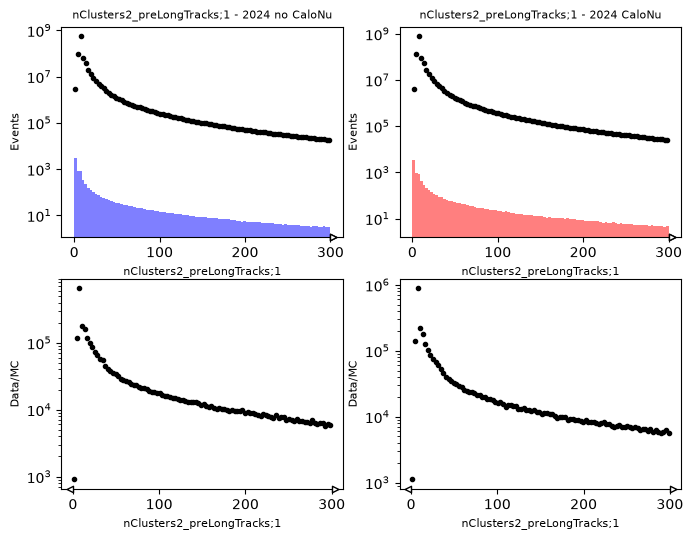

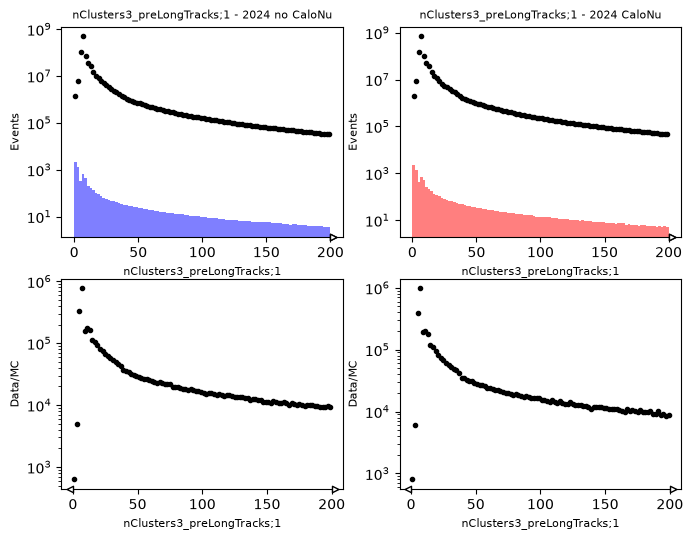

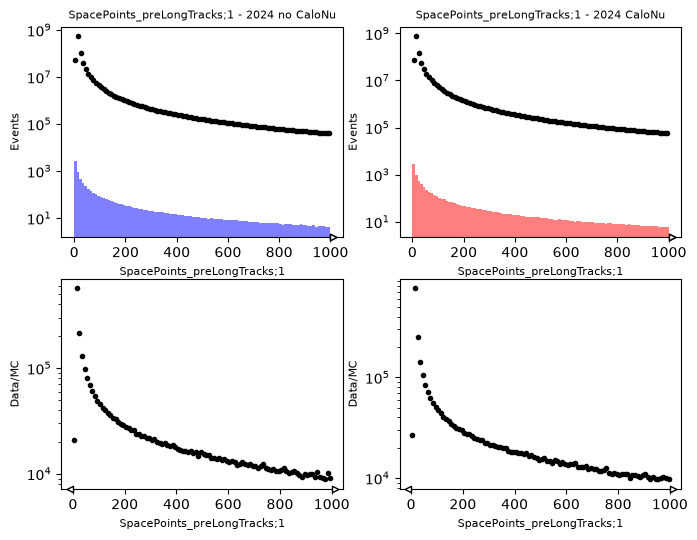

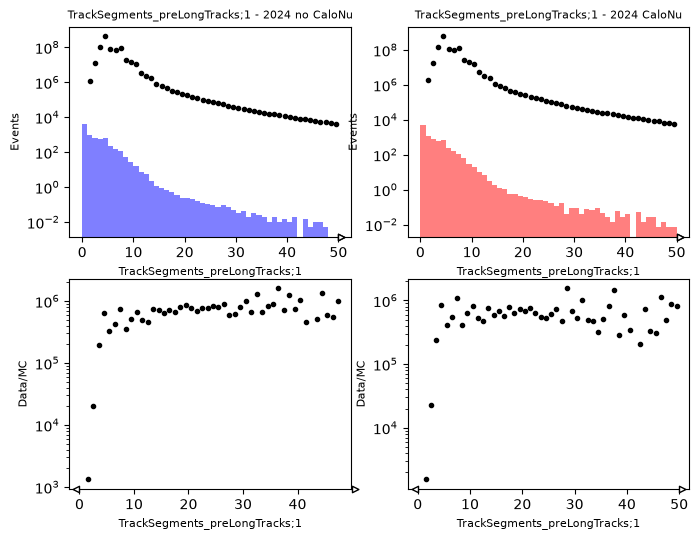

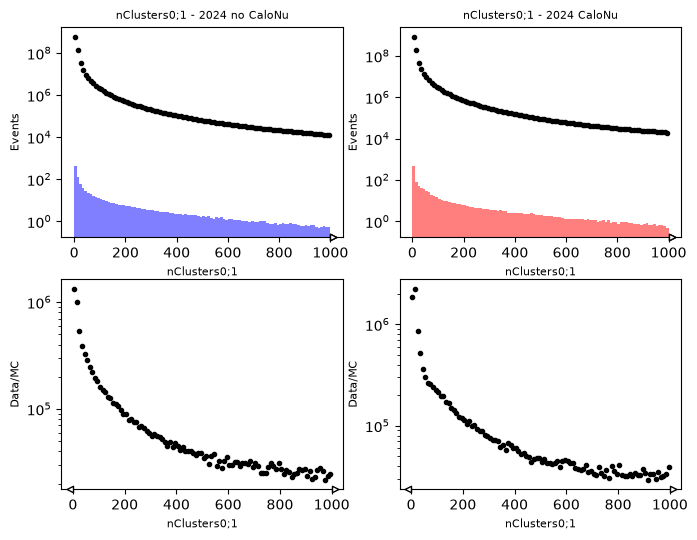

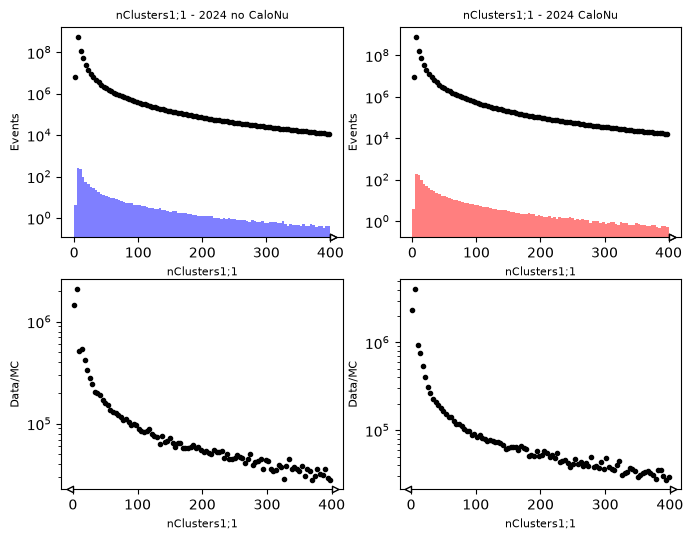

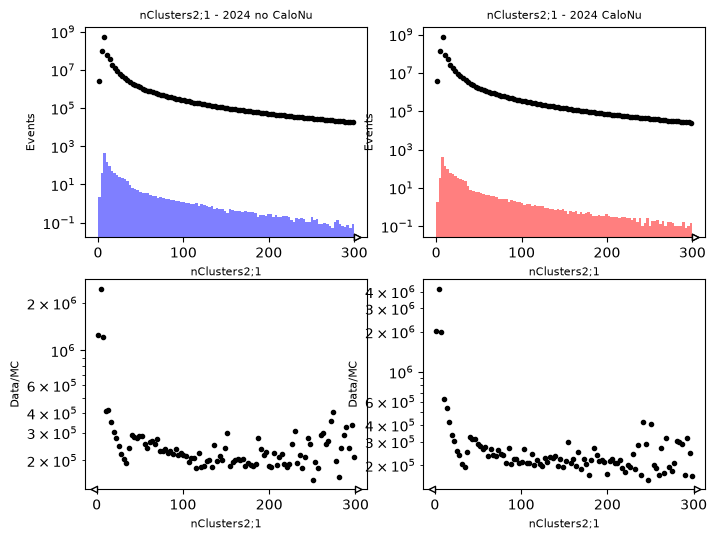

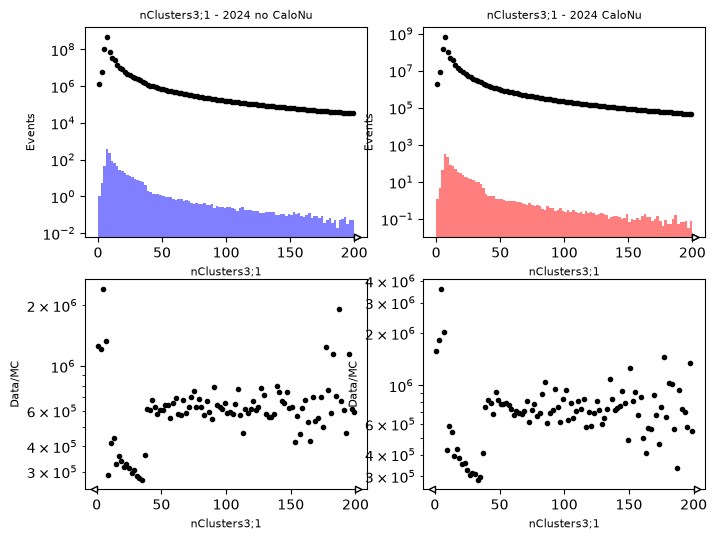

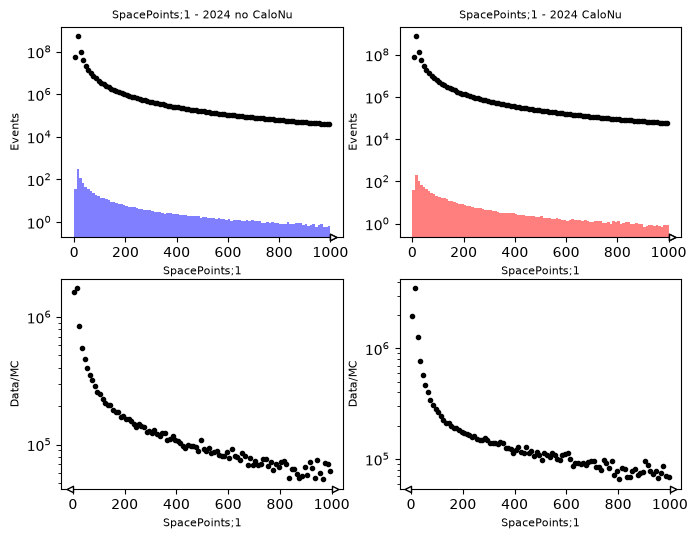

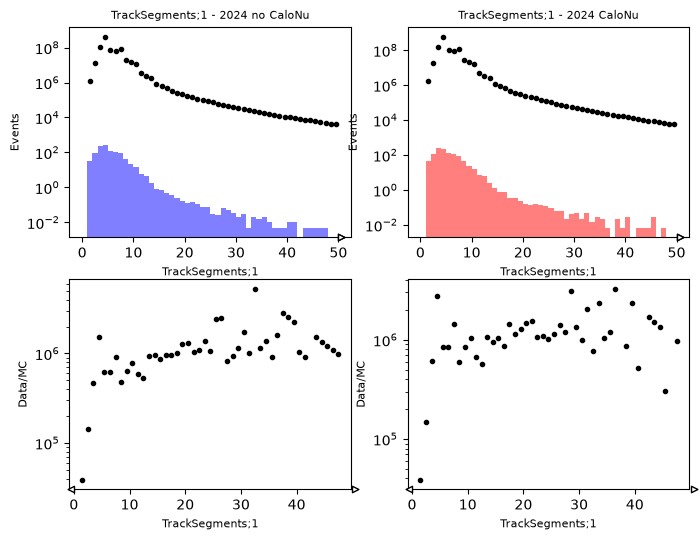

In [13]:
for hist_name in hists_to_plot:

    h_mc_noCaloNu = mc_2024_noCaloNu['histograms'][hist_name].to_boost()
    h_mc_CaloNu = mc_2024_CaloNu['histograms'][hist_name].to_boost()

    h_mc_noCaloNu *= lumi_2024_noCaloNu / 10_000
    h_mc_CaloNu *= lumi_2024_CaloNu / 10_000

    h_data_CaloNu = histograms_CaloNu[hist_name]
    h_data_noCaloNu = histograms_noCaloNu[hist_name]


    h_data_mc_ratio_noCaloNu = h_data_noCaloNu / h_mc_noCaloNu
    h_data_mc_ratio_CaloNu = h_data_CaloNu / h_mc_CaloNu

    fig, ax = plt.subplots(figsize=(8, 6), ncols=2, nrows=2)

    mplhep.histplot(h_mc_noCaloNu, ax=ax[0][0], label='MC 2024 no CaloNu', color='blue', histtype='fill', alpha=0.5)
    mplhep.histplot(h_data_noCaloNu, ax=ax[0][0], label='Data 2024 no CaloNu', color='black', histtype='errorbar', linewidth=1.5)

    mplhep.histplot(h_mc_CaloNu, ax=ax[0][1], label='MC 2024 CaloNu', color='red', histtype='fill', alpha=0.5)
    mplhep.histplot(h_data_CaloNu, ax=ax[0][1], label='Data 2024 CaloNu', color='black', histtype='errorbar', linewidth=1.5)

    mplhep.histplot(h_data_mc_ratio_noCaloNu, ax=ax[1][0], label='Data/MC 2024 no CaloNu', color='black', histtype='errorbar', linewidth=1.5)
    mplhep.histplot(h_data_mc_ratio_CaloNu, ax=ax[1][1], label='Data/MC 2024 CaloNu', color='black', histtype='errorbar', linewidth=1.5)

    ax[0][0].set_title(f"{hist_name} - 2024 no CaloNu", fontsize=8)
    ax[0][1].set_title(f"{hist_name} - 2024 CaloNu", fontsize=8)

    ax[0][0].set_xlabel(hist_name, fontsize=8)
    ax[0][1].set_xlabel(hist_name, fontsize=8)

    ax[0][0].set_ylabel("Events", fontsize=8)
    ax[0][1].set_ylabel("Events", fontsize=8)

    ax[1][0].set_xlabel(hist_name, fontsize=8)
    ax[1][1].set_xlabel(hist_name, fontsize=8)

    ax[1][0].set_ylabel("Data/MC", fontsize=8)
    ax[1][1].set_ylabel("Data/MC", fontsize=8)
    
    ax[0][0].set_yscale('log')
    ax[0][1].set_yscale('log')
    ax[1][0].set_yscale('log')
    ax[1][1].set_yscale('log')

    

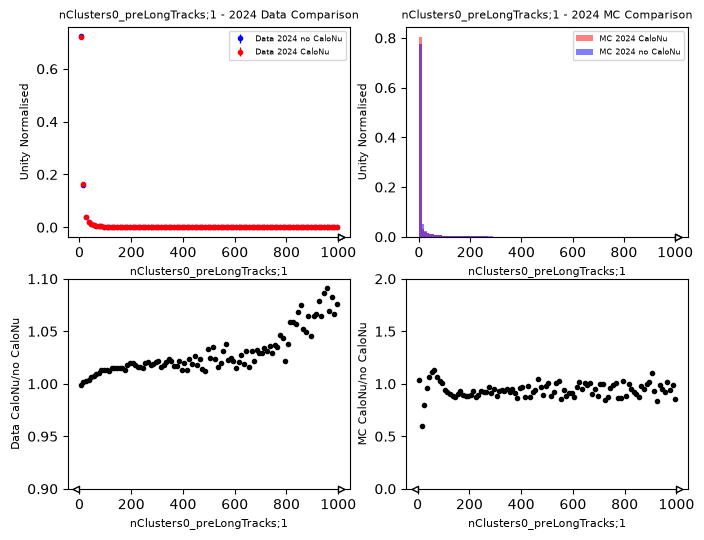

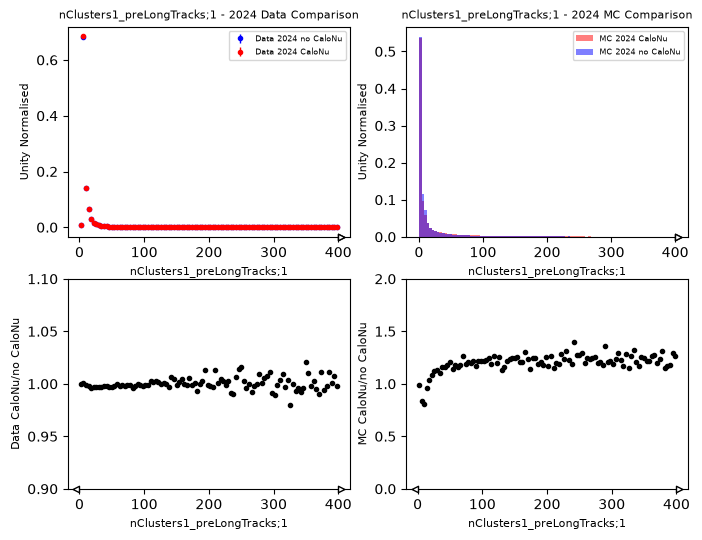

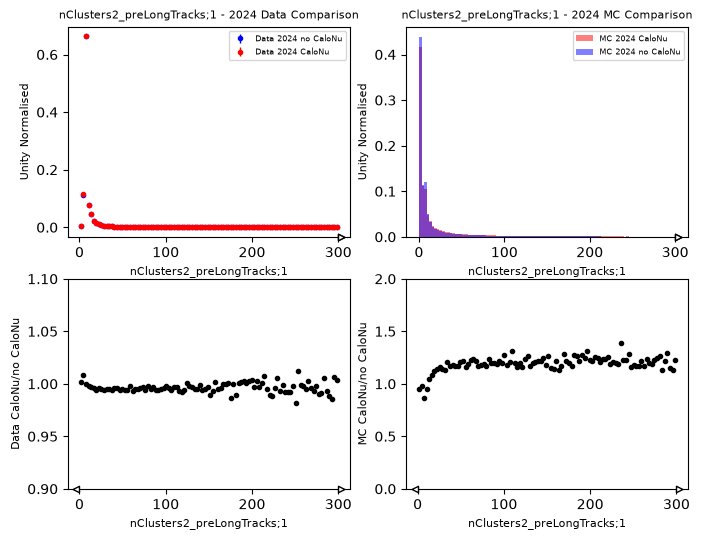

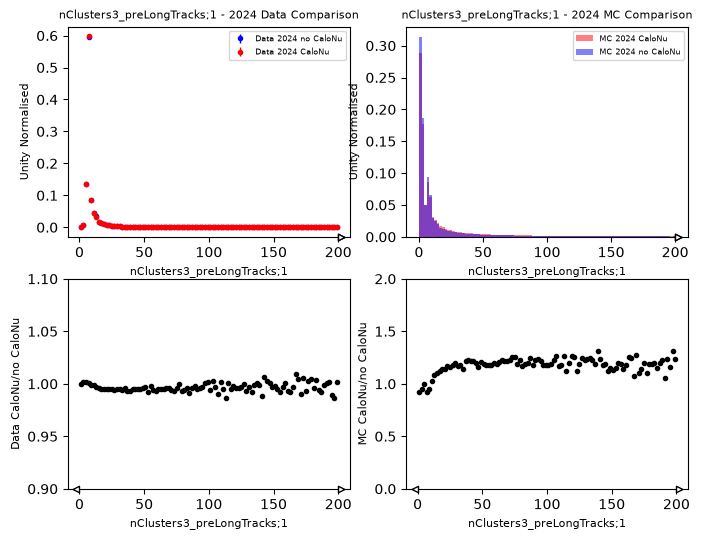

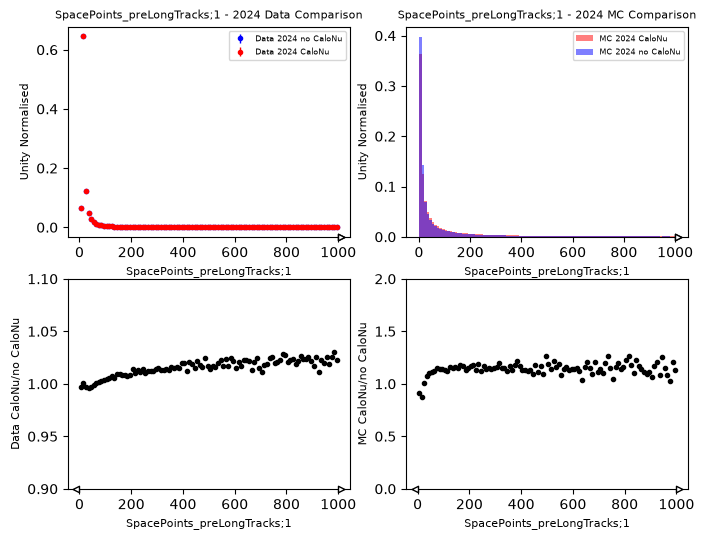

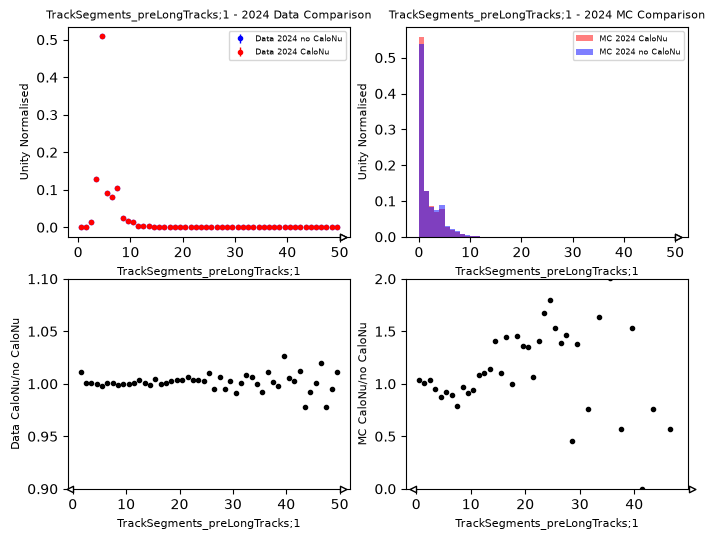

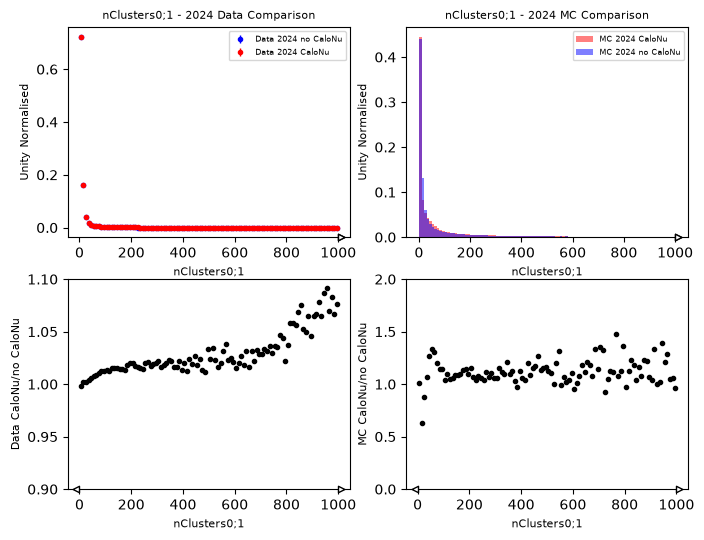

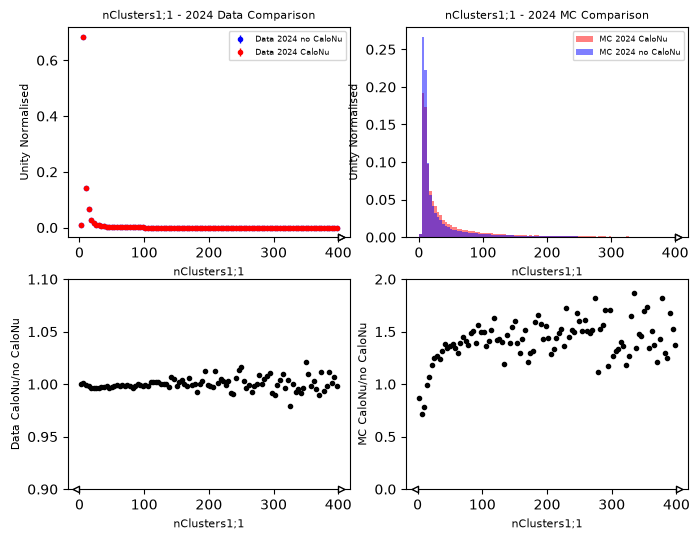

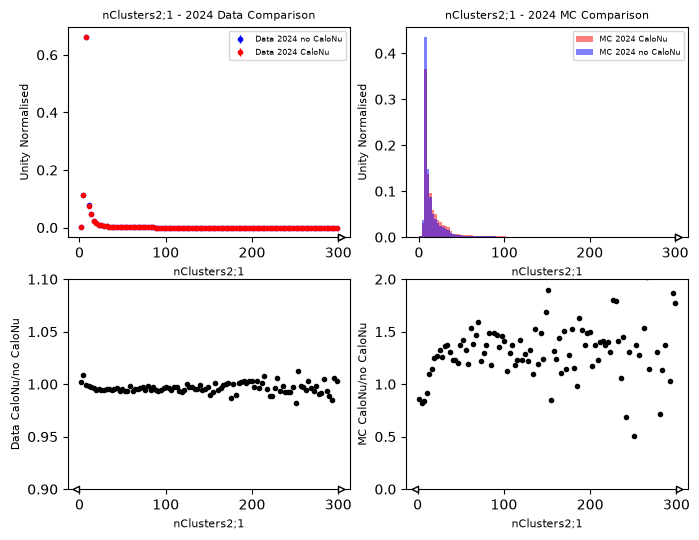

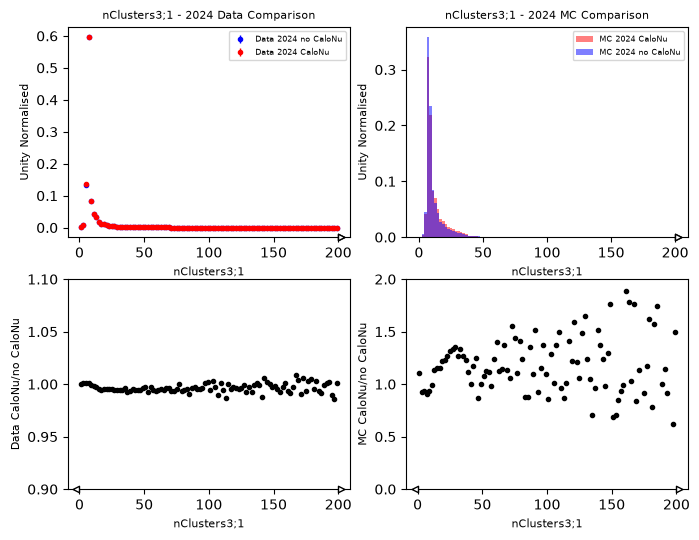

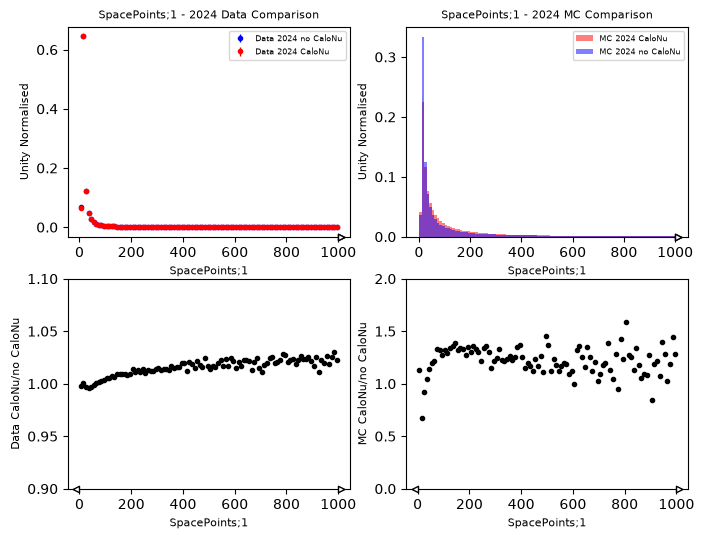

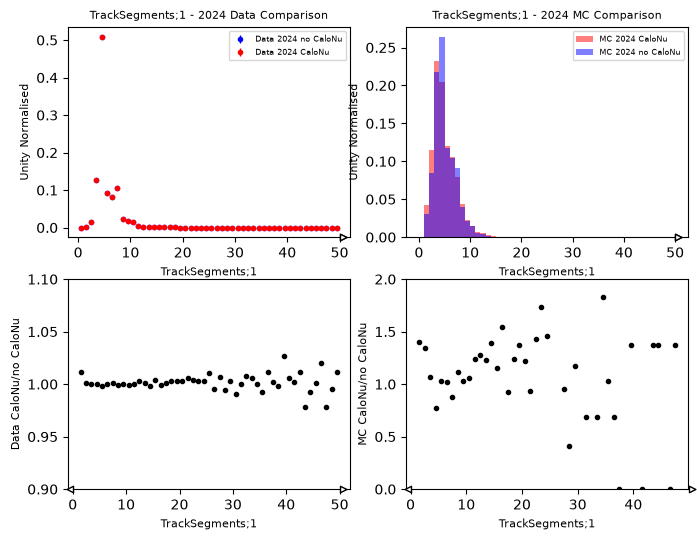

In [14]:
for hist_name in hists_to_plot:

    h_mc_noCaloNu = mc_2024_noCaloNu['histograms'][hist_name].to_boost()
    h_mc_CaloNu = mc_2024_CaloNu['histograms'][hist_name].to_boost()

    h_mc_noCaloNu *= lumi_2024_noCaloNu / 10_000
    h_mc_CaloNu *= lumi_2024_CaloNu / 10_000

    h_data_CaloNu = deepcopy(histograms_CaloNu[hist_name])
    h_data_noCaloNu = deepcopy(histograms_noCaloNu[hist_name])

    # Normalise to unity
    h_data_CaloNu /= h_data_CaloNu.sum()
    h_data_noCaloNu /= h_data_noCaloNu.sum()

    h_mc_noCaloNu /= h_mc_noCaloNu.sum()
    h_mc_CaloNu /= h_mc_CaloNu.sum()

    h_data_caloNu_over_data_noCaloNu = h_data_CaloNu / h_data_noCaloNu
    h_mc_caloNu_over_mc_noCaloNu = h_mc_CaloNu / h_mc_noCaloNu


    fig, ax = plt.subplots(figsize=(8, 6), ncols=2, nrows=2)

    mplhep.histplot(h_data_noCaloNu, ax=ax[0][0], label='Data 2024 no CaloNu', color='blue', histtype='errorbar', linewidth=1.5)
    mplhep.histplot(h_data_CaloNu, ax=ax[0][0], label='Data 2024 CaloNu', color='red', histtype='errorbar', linewidth=1.5)

    mplhep.histplot(h_mc_CaloNu, ax=ax[0][1], label='MC 2024 CaloNu', color='red', histtype='fill', alpha=0.5)
    mplhep.histplot(h_mc_noCaloNu, ax=ax[0][1], label='MC 2024 no CaloNu', color='blue', histtype='fill', alpha=0.5)

    mplhep.histplot(h_data_caloNu_over_data_noCaloNu, ax=ax[1][0], label='Data CaloNu/no CaloNu', color='black', histtype='errorbar', linewidth=1.5)
    mplhep.histplot(h_mc_caloNu_over_mc_noCaloNu, ax=ax[1][1], label='MC CaloNu/no CaloNu', color='black', histtype='errorbar', linewidth=1.5)

    ax[0][0].set_title(f"{hist_name} - 2024 Data Comparison", fontsize=8)
    ax[0][1].set_title(f"{hist_name} - 2024 MC Comparison", fontsize=8)

    ax[0][0].legend(fontsize=6)
    ax[0][1].legend(fontsize=6)


    ax[0][0].set_xlabel(hist_name, fontsize=8)
    ax[0][1].set_xlabel(hist_name, fontsize=8)

    ax[0][0].set_ylabel("Unity Normalised", fontsize=8)
    ax[0][1].set_ylabel("Unity Normalised", fontsize=8)

    ax[1][0].set_xlabel(hist_name, fontsize=8)
    ax[1][1].set_xlabel(hist_name, fontsize=8)

    ax[1][0].set_ylabel("Data CaloNu/no CaloNu", fontsize=8)
    ax[1][1].set_ylabel("MC CaloNu/no CaloNu", fontsize=8)

    ax[1][0].set_ylim(0.9, 1.1)
    ax[1][1].set_ylim(0, 2)

    # ax[0][0].set_yscale('log')
    # ax[0][1].set_yscale('log')
    # ax[1][0].set_yscale('log')
    # ax[1][1].set_yscale('log')

    

In [15]:
axis = bh.axis.Variable(np.logspace(0, 4, 20))

h_sp_data_noCaloNu = bh.Histogram(axis, storage=bh.storage.Weight())
h_sp_data_CaloNu = bh.Histogram(axis, storage=bh.storage.Weight())

h_sp_mc_noCaloNu = bh.Histogram(axis    , storage=bh.storage.Weight())
h_sp_mc_CaloNu = bh.Histogram(axis, storage=bh.storage.Weight())

In [16]:
for file in tqdm.tqdm(non_caloNu_2024_data_files):
    with uproot.open(file) as root_file:
        try:
            h_sp_data_noCaloNu.fill(root_file['nt'].arrays("SpacePoints", library="ak")["SpacePoints"])
        except KeyError as e:
            print(e)
            continue

100%|██████████| 146/146 [00:22<00:00,  6.60it/s]


In [17]:
for file in tqdm.tqdm(calonu_data_files):
    with uproot.open(file) as root_file:
        try:
            h_sp_data_CaloNu.fill(root_file['nt'].arrays("SpacePoints", library="ak")["SpacePoints"])
        except KeyError as e:
            print(e)
            continue

 68%|██████▊   | 89/130 [00:15<00:05,  7.64it/s]

not found: 'nt' (with any cycle number)

    Available keys: (none!)

in file AnalysisZipFramework/submission/analysis_output-moreHists/16098.root


100%|██████████| 130/130 [00:22<00:00,  5.73it/s]


In [18]:
h_sp_mc_CaloNu.fill(mc_2024_CaloNu['nt'].arrays("SpacePoints", library="ak")["SpacePoints"])
h_sp_mc_noCaloNu.fill(mc_2024_noCaloNu['nt'].arrays("SpacePoints", library="ak")["SpacePoints"])

Histogram(Variable([1, 1.62378, 2.63665, 4.28133, 6.95193, 11.2884, 18.3298, 29.7635, 48.3293, 78.476, 127.427, 206.914, 335.982, 545.559, 885.867, 1438.45, 2335.72, 3792.69, 6158.48, 10000]), storage=Weight()) # Sum: WeightedSum(value=46065, variance=46065) (WeightedSum(value=46073, variance=46073) with flow)

(0.0, 5.0)

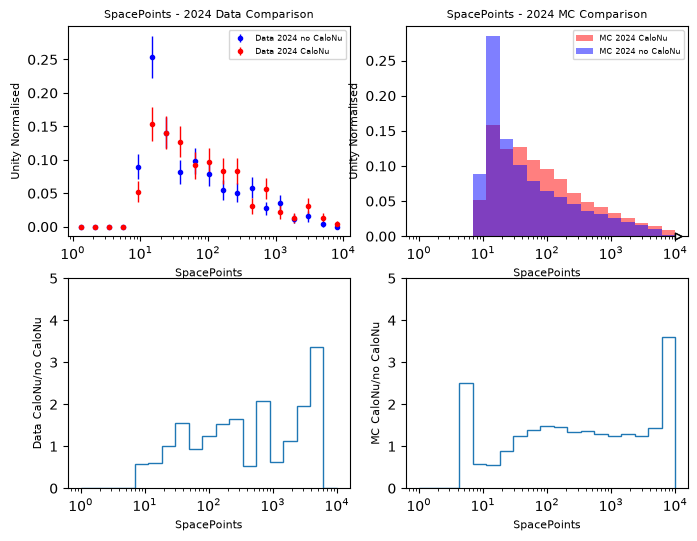

In [19]:
h_data_noCaloNu = deepcopy(h_sp_data_noCaloNu)
h_data_CaloNu = deepcopy(h_sp_data_CaloNu)

h_mc_noCaloNu = deepcopy(h_sp_mc_noCaloNu)
h_mc_CaloNu = deepcopy(h_sp_mc_CaloNu)

# normalise to unity
h_data_noCaloNu = h_data_noCaloNu / h_data_noCaloNu.sum().value
h_data_CaloNu = h_data_CaloNu / h_data_CaloNu.sum().value

h_mc_noCaloNu = h_mc_noCaloNu / h_mc_noCaloNu.sum().value
h_mc_CaloNu = h_mc_CaloNu / h_mc_CaloNu.sum().value

# Extract bin contents
data_noCaloNu = h_data_noCaloNu.view().value
data_CaloNu = h_data_CaloNu.view().value

mc_noCaloNu = h_mc_noCaloNu.view().value
mc_CaloNu = h_mc_CaloNu.view().value

# Ratios
h_data_caloNu_over_data_noCaloNu = np.divide(
    data_CaloNu,
    data_noCaloNu,
    out=np.zeros_like(data_CaloNu, dtype=float),
    where=data_noCaloNu != 0,
)

h_mc_caloNu_over_mc_noCaloNu = np.divide(
    mc_CaloNu,
    mc_noCaloNu,
    out=np.zeros_like(mc_CaloNu, dtype=float),
    where=mc_noCaloNu != 0,
)


fig, ax = plt.subplots(figsize=(8, 6), ncols=2, nrows=2)

hist_name = "SpacePoints"

mplhep.histplot(h_data_noCaloNu, ax=ax[0][0], label='Data 2024 no CaloNu', color='blue', histtype='errorbar', linewidth=1.5)
mplhep.histplot(h_data_CaloNu, ax=ax[0][0], label='Data 2024 CaloNu', color='red', histtype='errorbar', linewidth=1.5)

mplhep.histplot(h_mc_CaloNu, ax=ax[0][1], label='MC 2024 CaloNu', color='red', histtype='fill', alpha=0.5)
mplhep.histplot(h_mc_noCaloNu, ax=ax[0][1], label='MC 2024 no CaloNu', color='blue', histtype='fill', alpha=0.5)

ax[1, 0].stairs(
    h_data_caloNu_over_data_noCaloNu,
    h_data_noCaloNu.axes[0].edges,
)
ax[1, 1].stairs(
    h_mc_caloNu_over_mc_noCaloNu,
    h_mc_noCaloNu.axes[0].edges,
)

ax[0][0].set_title(f"{hist_name} - 2024 Data Comparison", fontsize=8)
ax[0][1].set_title(f"{hist_name} - 2024 MC Comparison", fontsize=8)

ax[0][0].legend(fontsize=6)
ax[0][1].legend(fontsize=6)


ax[0][0].set_xlabel(hist_name, fontsize=8)
ax[0][1].set_xlabel(hist_name, fontsize=8)

ax[0][0].set_ylabel("Unity Normalised", fontsize=8)
ax[0][1].set_ylabel("Unity Normalised", fontsize=8)

ax[1][0].set_xlabel(hist_name, fontsize=8)
ax[1][1].set_xlabel(hist_name, fontsize=8)

ax[1][0].set_ylabel("Data CaloNu/no CaloNu", fontsize=8)
ax[1][1].set_ylabel("MC CaloNu/no CaloNu", fontsize=8)

# ax[0][0].set_xlim(0, 300)
# ax[0][1].set_xlim(0, 300)
# ax[1][0].set_xlim(0, 300)
# ax[1][1].set_xlim(0, 300)

ax[0][0].set_xscale("log")
ax[0][1].set_xscale("log")
ax[1][0].set_xscale("log")
ax[1][1].set_xscale("log")

ax[1][0].set_ylim(0, 5)
ax[1][1].set_ylim(0, 5)

In [20]:
def hist_ratio(h_num, h_den, normalise=False):
    num_vals = h_num.values()
    den_vals = h_den.values()
    num_vars = h_num.variances()
    den_vars = h_den.variances()

    if normalise:
        num_vals = num_vals / np.sum(num_vals)
        den_vals = den_vals / np.sum(den_vals)
        num_vars = num_vars / (np.sum(num_vals) ** 2)
        den_vars = den_vars / (np.sum(den_vals) ** 2)

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(den_vals != 0, num_vals / den_vals, np.nan)
        # standard error propagation for a ratio R = A/B:
        # (sigma_R/R)^2 = (sigma_A/A)^2 + (sigma_B/B)^2
        rel_err = np.sqrt(
            np.where(num_vals != 0, num_vars / num_vals**2, 0)
            + np.where(den_vals != 0, den_vars / den_vals**2, 0)
        )
        ratio_err = ratio * rel_err

    return ratio, ratio_err

MC Scale 2024 no CaloNu: 50.1 / 10_000 = 0.005
MC Scale 2024 CaloNu: 70.03 / 10_000 = 0.007


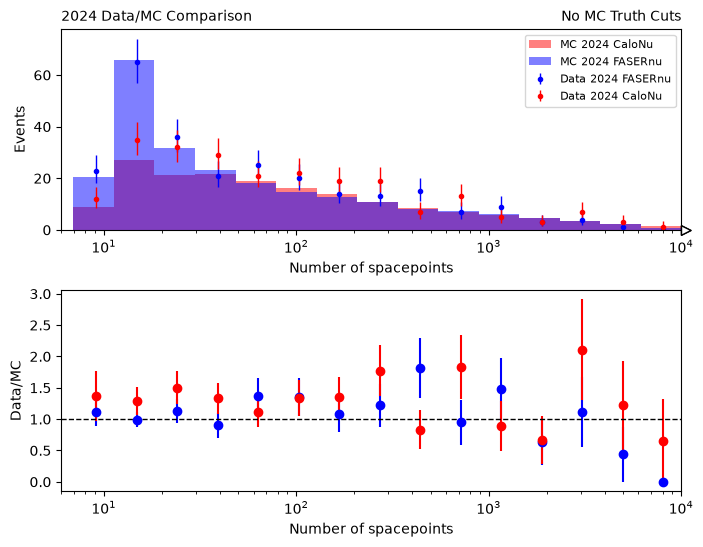

In [21]:
h_data_noCaloNu = deepcopy(h_sp_data_noCaloNu)
h_data_CaloNu = deepcopy(h_sp_data_CaloNu)

h_mc_noCaloNu = deepcopy(h_sp_mc_noCaloNu)
h_mc_CaloNu = deepcopy(h_sp_mc_CaloNu)

h_mc_noCaloNu *= lumi_2024_noCaloNu / 10_000
h_mc_CaloNu *= lumi_2024_CaloNu / 10_000

print(f"MC Scale 2024 no CaloNu: {lumi_2024_noCaloNu} / 10_000 = {lumi_2024_noCaloNu / 10_000:.2g}")
print(f"MC Scale 2024 CaloNu: {lumi_2024_CaloNu} / 10_000 = {lumi_2024_CaloNu / 10_000:.2g}")

h_noCaloNu_ratio = hist_ratio(h_data_noCaloNu, h_mc_noCaloNu)
h_CaloNu_ratio = hist_ratio(h_data_CaloNu, h_mc_CaloNu)


fig, ax = plt.subplots(figsize=(8, 6), ncols=1, nrows=2)

# ax = [ax]

hist_name = "SpacePoints"

mplhep.histplot(h_data_noCaloNu, ax=ax[0], label='Data 2024 FASERnu', color='blue', histtype='errorbar', linewidth=1.5)
mplhep.histplot(h_data_CaloNu, ax=ax[0], label='Data 2024 CaloNu', color='red', histtype='errorbar', linewidth=1.5)

mplhep.histplot(h_mc_CaloNu, ax=ax[0], label='MC 2024 CaloNu', color='red', histtype='fill', alpha=0.5)
mplhep.histplot(h_mc_noCaloNu, ax=ax[0], label='MC 2024 FASERnu', color='blue', histtype='fill', alpha=0.5)

ax[0].set_title(f"2024 Data/MC Comparison", fontsize=10, loc='left')
ax[0].set_title(f"No MC Truth Cuts", fontsize=10, loc='right')
ax[0].legend(fontsize=8)
ax[0].set_xlabel("Number of spacepoints", fontsize=10)
ax[0].set_ylabel("Events", fontsize=10)
ax[0].set_xscale("log")
ax[0].set_xlim(6, 1e4)

fig.subplots_adjust(hspace=0.3)

bin_centers = h_data_noCaloNu.axes[0].centers
ax[1].errorbar(bin_centers, h_noCaloNu_ratio[0], yerr=h_noCaloNu_ratio[1], fmt='o', label='Data/MC 2024 FASERnu', color='blue')
ax[1].errorbar(bin_centers, h_CaloNu_ratio[0], yerr=h_CaloNu_ratio[1], fmt='o', label='Data/MC 2024 CaloNu', color='red')
ax[1].set_xlabel("Number of spacepoints", fontsize=10)
ax[1].set_ylabel("Data/MC", fontsize=10)
ax[1].set_xscale("log")
ax[1].set_xlim(6, 1e4)
ax[1].axhline(y=1, color='black', linestyle='--', linewidth=1)


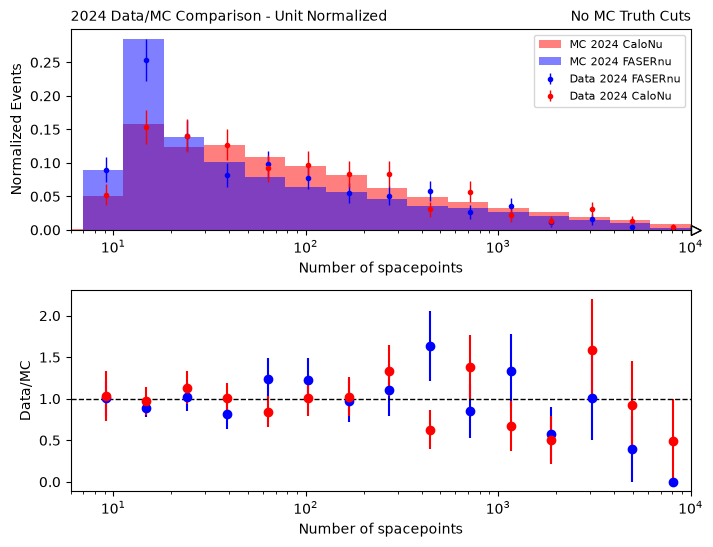

In [22]:
h_data_noCaloNu = deepcopy(h_sp_data_noCaloNu)
h_data_CaloNu = deepcopy(h_sp_data_CaloNu)

h_mc_noCaloNu = deepcopy(h_sp_mc_noCaloNu)
h_mc_CaloNu = deepcopy(h_sp_mc_CaloNu)

# Normalise data and MC to unity
h_data_noCaloNu *= 1.0 / h_data_noCaloNu.sum().value
h_data_CaloNu *= 1.0 / h_data_CaloNu.sum().value
h_mc_noCaloNu *= 1.0 / h_mc_noCaloNu.sum().value
h_mc_CaloNu *= 1.0 / h_mc_CaloNu.sum().value

h_noCaloNu_ratio = hist_ratio(h_data_noCaloNu, h_mc_noCaloNu)
h_CaloNu_ratio = hist_ratio(h_data_CaloNu, h_mc_CaloNu)


fig, ax = plt.subplots(figsize=(8, 6), ncols=1, nrows=2)

# ax = [ax]

hist_name = "SpacePoints"

mplhep.histplot(h_data_noCaloNu, ax=ax[0], label='Data 2024 FASERnu', color='blue', histtype='errorbar', linewidth=1.5)
mplhep.histplot(h_data_CaloNu, ax=ax[0], label='Data 2024 CaloNu', color='red', histtype='errorbar', linewidth=1.5)

mplhep.histplot(h_mc_CaloNu, ax=ax[0], label='MC 2024 CaloNu', color='red', histtype='fill', alpha=0.5)
mplhep.histplot(h_mc_noCaloNu, ax=ax[0], label='MC 2024 FASERnu', color='blue', histtype='fill', alpha=0.5)

ax[0].set_title(f"2024 Data/MC Comparison - Unit Normalized", fontsize=10, loc='left')
ax[0].set_title(f"No MC Truth Cuts", fontsize=10, loc='right')
ax[0].legend(fontsize=8)
ax[0].set_xlabel("Number of spacepoints", fontsize=10)
ax[0].set_ylabel("Normalized Events", fontsize=10)
ax[0].set_xscale("log")
ax[0].set_xlim(6, 1e4)

fig.subplots_adjust(hspace=0.3)

bin_centers = h_data_noCaloNu.axes[0].centers
ax[1].errorbar(bin_centers, h_noCaloNu_ratio[0], yerr=h_noCaloNu_ratio[1], fmt='o', label='Data/MC 2024 FASERnu', color='blue')
ax[1].errorbar(bin_centers, h_CaloNu_ratio[0], yerr=h_CaloNu_ratio[1], fmt='o', label='Data/MC 2024 CaloNu', color='red')
ax[1].set_xlabel("Number of spacepoints", fontsize=10)
ax[1].set_ylabel("Data/MC", fontsize=10)
ax[1].set_xscale("log")
ax[1].set_xlim(6, 1e4)
ax[1].axhline(y=1, color='black', linestyle='--', linewidth=1)


In [23]:
# def plot_histogram_comparison(variable, bins, data_noCaloNu_files, data_CaloNu_files, mc_noCaloNu_files, mc_CaloNu_files):
    
#     axis = bh.axis.Variable(bins)

#     h_data_noCaloNu = bh.Histogram(axis, storage=bh.storage.Weight())
#     h_data_CaloNu = bh.Histogram(axis, storage=bh.storage.Weight())

#     h_mc_noCaloNu = bh.Histogram(axis, storage=bh.storage.Weight())
#     h_mc_CaloNu = bh.Histogram(axis, storage=bh.storage.Weight())
    
#     for file in tqdm.tqdm(mc_CaloNu_files):
#         with uproot.open(file) as root_file:
#             try:
#                 h_mc_CaloNu.fill(root_file['nt'].arrays(variable, library="ak")[variable], weight=70.03 / 10_000)
#             except KeyError as e:
#                 print(e)
#                 continue
            
#     for file in tqdm.tqdm(mc_noCaloNu_files):
#         with uproot.open(file) as root_file:
#             try:
#                 h_mc_noCaloNu.fill(root_file['nt'].arrays(variable, library="ak")[variable], weight=50.10 / 10_000)
#             except KeyError as e:
#                 print(e)
#                 continue

#     for file in tqdm.tqdm(data_noCaloNu_files):
#         with uproot.open(file) as root_file:
#             try:
#                 h_data_noCaloNu.fill(root_file['nt'].arrays(variable, library="ak")[variable])
#             except KeyError as e:
#                 print(e)
#                 continue

#     for file in tqdm.tqdm(data_CaloNu_files):
#         with uproot.open(file) as root_file:
#             try:
#                 h_data_CaloNu.fill(root_file['nt'].arrays(variable, library="ak")[variable])
#             except KeyError as e:
#                 print(e)
#                 continue

    
#     # h_mc_CaloNu.fill(mc_CaloNu_files['nt'].arrays(variable, library="ak")[variable], weight=70.03 / 10_000)
#     # h_mc_noCaloNu.fill(mc_noCaloNu_files['nt'].arrays(variable, library="ak")[variable], weight=50.10 / 10_000)

#     # h_no_caloNu_data_mc_ratio = h_data_noCaloNu / h_mc_noCaloNu
#     # h_caloNu_data_mc_ratio = h_data_CaloNu / h_mc_CaloNu


#     fig, ax = plt.subplots(figsize=(8, 6), ncols=2, nrows=2)

#     mplhep.histplot(h_data_noCaloNu, ax=ax[0][0], label='Data 2024 no CaloNu', color='black', histtype='errorbar', linewidth=1.5)
#     mplhep.histplot(h_mc_noCaloNu, ax=ax[0][0], label='MC 2024 no CaloNu', color='blue', histtype='fill', linewidth=1.5)

#     mplhep.histplot(h_data_CaloNu, ax=ax[0][1], label='Data 2024 CaloNu', color='black', histtype='errorbar', linewidth=1.5)
#     mplhep.histplot(h_mc_CaloNu, ax=ax[0][1], label='MC 2024 CaloNu', color='red', histtype='fill', linewidth=1.5)

#     # mplhep.histplot(h_no_caloNu_data_mc_ratio, ax=ax[1][0], label='Data/MC 2024 no CaloNu', color='black', histtype='errorbar', linewidth=1.5)
#     # mplhep.histplot(h_caloNu_data_mc_ratio, ax=ax[1][1], label='Data/MC 2024 CaloNu', color='black', histtype='errorbar', linewidth=1.5)

#     ax[0][0].set_yscale('log')
#     ax[0][1].set_yscale('log')
#     ax[0][0].set_xlabel(variable)
#     ax[0][1].set_xlabel(variable)
#     ax[0][0].set_ylabel("Events")
#     ax[0][1].set_ylabel("Events")
#     ax[1][0].set_xlabel(variable)
#     ax[1][1].set_xlabel(variable)
#     ax[1][0].set_ylabel("Data/MC")
#     ax[1][1].set_ylabel("Data/MC")
#     ax[0][0].legend()
#     ax[0][1].legend()


In [24]:
def plot_histogram_comparison(variable, bins, data_noCaloNu_files, data_CaloNu_files, mc_noCaloNu_files, mc_CaloNu_files, density=False):
    
    binwnorm = not density  # Set binwnorm to True if density is False, and vice versa

    axis = bh.axis.Variable(bins)

    h_data_noCaloNu = bh.Histogram(axis, storage=bh.storage.Weight())
    h_data_CaloNu = bh.Histogram(axis, storage=bh.storage.Weight())

    h_mc_noCaloNu = bh.Histogram(axis, storage=bh.storage.Weight())
    h_mc_CaloNu = bh.Histogram(axis, storage=bh.storage.Weight())
    
    for file in tqdm.tqdm(mc_CaloNu_files):
        with uproot.open(file) as root_file:
            try:
                h_mc_CaloNu.fill(root_file['nt'].arrays(variable, library="ak")[variable], weight=70.03 / 10_000)
            except KeyError as e:
                print(e)
                continue
            
    for file in tqdm.tqdm(mc_noCaloNu_files):
        with uproot.open(file) as root_file:
            try:
                h_mc_noCaloNu.fill(root_file['nt'].arrays(variable, library="ak")[variable], weight=50.10 / 10_000)
            except KeyError as e:
                print(e)
                continue

    for file in tqdm.tqdm(data_noCaloNu_files):
        with uproot.open(file) as root_file:
            try:
                h_data_noCaloNu.fill(root_file['nt'].arrays(variable, library="ak")[variable])
            except KeyError as e:
                print(e)
                continue

    for file in tqdm.tqdm(data_CaloNu_files):
        with uproot.open(file) as root_file:
            try:
                h_data_CaloNu.fill(root_file['nt'].arrays(variable, library="ak")[variable])
            except KeyError as e:
                print(e)
                continue

    
    # h_mc_CaloNu.fill(mc_CaloNu_files['nt'].arrays(variable, library="ak")[variable], weight=70.03 / 10_000)
    # h_mc_noCaloNu.fill(mc_noCaloNu_files['nt'].arrays(variable, library="ak")[variable], weight=50.10 / 10_000)

    # h_no_caloNu_data_mc_ratio = h_data_noCaloNu / h_mc_noCaloNu
    # h_caloNu_data_mc_ratio = h_data_CaloNu / h_mc_CaloNu


    fig, ax = plt.subplots(figsize=(12, 6), ncols=2)

    if density:

        mplhep.histplot(h_data_noCaloNu, ax=ax[0], label='Data 2024 no CaloNu', color='black', histtype='errorbar', linewidth=1.5, density=density)
        mplhep.histplot(h_mc_noCaloNu, ax=ax[0], label='MC 2024 no CaloNu', color='blue', histtype='fill', linewidth=1.5,  density=density)

        mplhep.histplot(h_data_CaloNu, ax=ax[1], label='Data 2024 CaloNu', color='black', histtype='errorbar', linewidth=1.5, density=density)
        mplhep.histplot(h_mc_CaloNu, ax=ax[1], label='MC 2024 CaloNu', color='red', histtype='fill', linewidth=1.5, density=density)
    else:
        mplhep.histplot(h_data_noCaloNu, ax=ax[0], label='Data 2024 no CaloNu', color='black', histtype='errorbar', linewidth=1.5,  binwnorm=binwnorm)
        mplhep.histplot(h_mc_noCaloNu, ax=ax[0], label='MC 2024 no CaloNu', color='blue', histtype='fill', linewidth=1.5, binwnorm=binwnorm)

        mplhep.histplot(h_data_CaloNu, ax=ax[1], label='Data 2024 CaloNu', color='black', histtype='errorbar', linewidth=1.5, binwnorm=binwnorm)
        mplhep.histplot(h_mc_CaloNu, ax=ax[1], label='MC 2024 CaloNu', color='red', histtype='fill', linewidth=1.5, binwnorm=binwnorm)

    # mplhep.histplot(h_no_caloNu_data_mc_ratio, ax=ax[1][0], label='Data/MC 2024 no CaloNu', color='black', histtype='errorbar', linewidth=1.5)
    # mplhep.histplot(h_caloNu_data_mc_ratio, ax=ax[1][1], label='Data/MC 2024 CaloNu', color='black', histtype='errorbar', linewidth=1.5)

    ax[0].set_yscale('log')
    ax[1].set_yscale('log')
    ax[0].set_xlabel(variable)
    ax[1].set_xlabel(variable)
    if not density:
        ax[0].set_ylabel("Events / pC")
        ax[1].set_ylabel("Events / pC")
    else:
        ax[0].set_ylabel("Unit Normalised Entries")
        ax[1].set_ylabel("Unit Normalised Entries")
    # ax[1][0].set_xlabel(variable)
    # ax[1][1].set_xlabel(variable)
    # ax[1][0].set_ylabel("Data/MC")
    # ax[1][1].set_ylabel("Data/MC")
    ax[0].legend()
    ax[1].legend()
    ax[0].set_ylim(1e-4, 1)
    ax[1].set_ylim(1e-4, 1)


 68%|██████▊   | 89/130 [00:16<00:05,  7.82it/s]

not found: 'nt' (with any cycle number)

    Available keys: (none!)

in file AnalysisZipFramework/submission/analysis_output-moreHists/16098.root


100%|██████████| 130/130 [00:23<00:00,  5.58it/s]


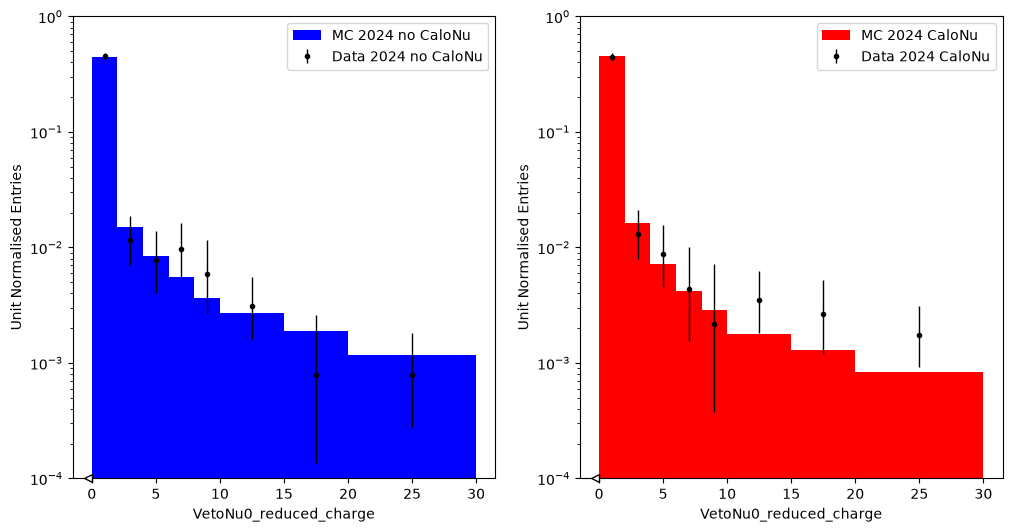

In [25]:
# bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30]
bins = [0, 2, 4, 6, 8, 10, 15, 20, 30]
plot_histogram_comparison("VetoNu0_reduced_charge", bins, non_caloNu_2024_data_files, calonu_data_files, ["build/MC_no_truth_cuts_fixed_ENFB8/2024_noCaloNu.bck.root"],[ "build/MC_no_truth_cuts_fixed_ENFB8/2024_CaloNu.bck.root"], density=True)

 67%|██████▋   | 87/130 [00:14<00:06,  6.65it/s]

not found: 'nt' (with any cycle number)

    Available keys: (none!)

in file AnalysisZipFramework/submission/analysis_output-moreHists/16098.root


100%|██████████| 130/130 [00:21<00:00,  5.93it/s]


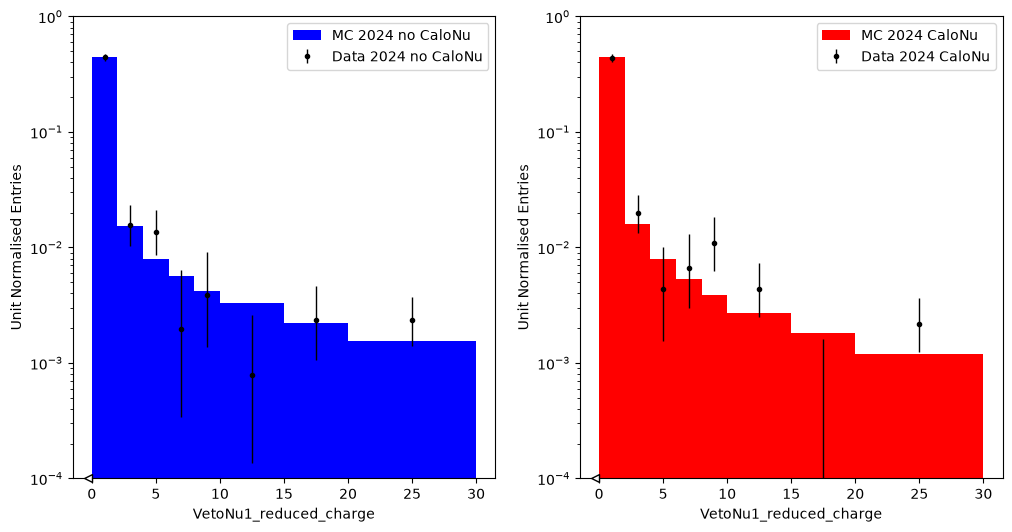

In [26]:
bins = [0, 2, 4, 6, 8, 10, 15, 20, 30]
plot_histogram_comparison("VetoNu1_reduced_charge", bins, non_caloNu_2024_data_files, calonu_data_files, ["build/MC_no_truth_cuts_fixed_ENFB8/2024_noCaloNu.bck.root"],[ "build/MC_no_truth_cuts_fixed_ENFB8/2024_CaloNu.bck.root"], density=True)

In [27]:
# axis = bh.axis.Variable(np.logspace(0, 2.9, 20))
axis = bh.axis.Variable([0, 4, 8, 12, 16, 20, 30, 40, 50, 75, 100])

h_ncls3_data_noCaloNu = bh.Histogram(axis, storage=bh.storage.Weight())
h_ncls3_data_CaloNu = bh.Histogram(axis, storage=bh.storage.Weight())

h_ncls3_mc_noCaloNu = bh.Histogram(axis    , storage=bh.storage.Weight())
h_ncls3_mc_CaloNu = bh.Histogram(axis, storage=bh.storage.Weight())

variable = "nClusters3"

for file in tqdm.tqdm(non_caloNu_2024_data_files):
    with uproot.open(file) as root_file:
        try:
            h_ncls3_data_noCaloNu.fill(root_file['nt'].arrays(variable, library="ak")[variable])
        except KeyError as e:
            print(e)
            continue

for file in tqdm.tqdm(calonu_data_files):
    with uproot.open(file) as root_file:
        try:
            h_ncls3_data_CaloNu.fill(root_file['nt'].arrays(variable, library="ak")[variable])
        except KeyError as e:
            print(e)
            continue

h_ncls3_mc_CaloNu.fill(mc_2024_CaloNu['nt'].arrays(variable, library="ak")[variable])
h_ncls3_mc_noCaloNu.fill(mc_2024_noCaloNu['nt'].arrays(variable, library="ak")[variable])

 67%|██████▋   | 87/130 [00:14<00:06,  6.40it/s]

not found: 'nt' (with any cycle number)

    Available keys: (none!)

in file AnalysisZipFramework/submission/analysis_output-moreHists/16098.root


100%|██████████| 130/130 [00:22<00:00,  5.87it/s]


Histogram(Variable([0, 4, 8, 12, 16, 20, 30, 40, 50, 75, 100]), storage=Weight()) # Sum: WeightedSum(value=45888, variance=45888) (WeightedSum(value=46073, variance=46073) with flow)

MC Scale 2024 no CaloNu: 50.1 / 10_000 = 0.005
MC Scale 2024 CaloNu: 70.03 / 10_000 = 0.007


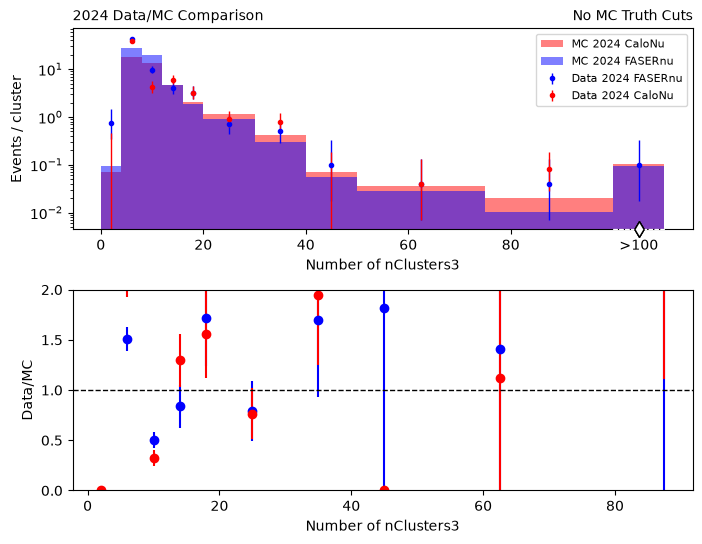

In [28]:
h_data_noCaloNu = deepcopy(h_ncls3_data_noCaloNu)
h_data_CaloNu = deepcopy(h_ncls3_data_CaloNu)

h_mc_noCaloNu = deepcopy(h_ncls3_mc_noCaloNu)
h_mc_CaloNu = deepcopy(h_ncls3_mc_CaloNu)

h_mc_noCaloNu *= lumi_2024_noCaloNu / 10_000
h_mc_CaloNu *= lumi_2024_CaloNu / 10_000

print(f"MC Scale 2024 no CaloNu: {lumi_2024_noCaloNu} / 10_000 = {lumi_2024_noCaloNu / 10_000:.2g}")
print(f"MC Scale 2024 CaloNu: {lumi_2024_CaloNu} / 10_000 = {lumi_2024_CaloNu / 10_000:.2g}")

h_noCaloNu_ratio = hist_ratio(h_data_noCaloNu, h_mc_noCaloNu)
h_CaloNu_ratio = hist_ratio(h_data_CaloNu, h_mc_CaloNu)


fig, ax = plt.subplots(figsize=(8, 6), ncols=1, nrows=2)

# ax = [ax]

hist_name = "nClusters3"

mplhep.histplot(h_data_noCaloNu, ax=ax[0], label='Data 2024 FASERnu', color='blue', histtype='errorbar', linewidth=1.5, binwnorm=True, flow='show')
mplhep.histplot(h_data_CaloNu, ax=ax[0], label='Data 2024 CaloNu', color='red', histtype='errorbar', linewidth=1.5, binwnorm=True, flow='show')

mplhep.histplot(h_mc_CaloNu, ax=ax[0], label='MC 2024 CaloNu', color='red', histtype='fill', alpha=0.5, binwnorm=True, flow='show')
mplhep.histplot(h_mc_noCaloNu, ax=ax[0], label='MC 2024 FASERnu', color='blue', histtype='fill', alpha=0.5, binwnorm=True, flow='show')

ax[0].set_title(f"2024 Data/MC Comparison", fontsize=10, loc='left')
ax[0].set_title(f"No MC Truth Cuts", fontsize=10, loc='right')
ax[0].legend(fontsize=8)
ax[0].set_xlabel("Number of nClusters3", fontsize=10)
ax[0].set_ylabel("Events / cluster", fontsize=10)
# ax[0].set_xscale("log")
ax[0].set_yscale("log")
# ax[0].set_xlim(0, 1e3)

fig.subplots_adjust(hspace=0.3)

bin_centers = h_data_noCaloNu.axes[0].centers
ax[1].errorbar(bin_centers, h_noCaloNu_ratio[0], yerr=h_noCaloNu_ratio[1], fmt='o', label='Data/MC 2024 FASERnu', color='blue')
ax[1].errorbar(bin_centers, h_CaloNu_ratio[0], yerr=h_CaloNu_ratio[1], fmt='o', label='Data/MC 2024 CaloNu', color='red')
ax[1].set_xlabel("Number of nClusters3", fontsize=10)
ax[1].set_ylabel("Data/MC", fontsize=10)
# ax[1].set_xscale("log")
# ax[1].set_xlim(6, 1e4)
ax[1].set_ylim(0, 2)
ax[1].axhline(y=1, color='black', linestyle='--', linewidth=1)


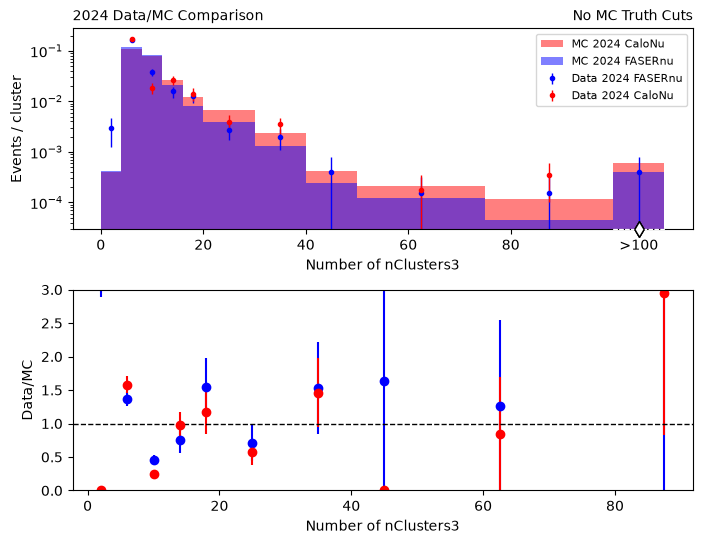

In [29]:
h_data_noCaloNu = deepcopy(h_ncls3_data_noCaloNu)
h_data_CaloNu = deepcopy(h_ncls3_data_CaloNu)

h_mc_noCaloNu = deepcopy(h_ncls3_mc_noCaloNu)
h_mc_CaloNu = deepcopy(h_ncls3_mc_CaloNu)

# Normalise data and MC to unity
h_data_noCaloNu *= 1.0 / h_data_noCaloNu.sum().value
h_data_CaloNu *= 1.0 / h_data_CaloNu.sum().value
h_mc_noCaloNu *= 1.0 / h_mc_noCaloNu.sum().value
h_mc_CaloNu *= 1.0 / h_mc_CaloNu.sum().value

h_noCaloNu_ratio = hist_ratio(h_data_noCaloNu, h_mc_noCaloNu)
h_CaloNu_ratio = hist_ratio(h_data_CaloNu, h_mc_CaloNu)


fig, ax = plt.subplots(figsize=(8, 6), ncols=1, nrows=2)

# ax = [ax]

hist_name = "nClusters3"

mplhep.histplot(h_data_noCaloNu, ax=ax[0], label='Data 2024 FASERnu', color='blue', histtype='errorbar', linewidth=1.5, binwnorm=True, flow='show')
mplhep.histplot(h_data_CaloNu, ax=ax[0], label='Data 2024 CaloNu', color='red', histtype='errorbar', linewidth=1.5, binwnorm=True, flow='show')

mplhep.histplot(h_mc_CaloNu, ax=ax[0], label='MC 2024 CaloNu', color='red', histtype='fill', alpha=0.5, binwnorm=True, flow='show')
mplhep.histplot(h_mc_noCaloNu, ax=ax[0], label='MC 2024 FASERnu', color='blue', histtype='fill', alpha=0.5, binwnorm=True, flow='show')

ax[0].set_title(f"2024 Data/MC Comparison", fontsize=10, loc='left')
ax[0].set_title(f"No MC Truth Cuts", fontsize=10, loc='right')
ax[0].legend(fontsize=8)
ax[0].set_xlabel("Number of nClusters3", fontsize=10)
ax[0].set_ylabel("Events / cluster", fontsize=10)
# ax[0].set_xscale("log")
ax[0].set_yscale("log")
# ax[0].set_xlim(0, 1e3)

fig.subplots_adjust(hspace=0.3)

bin_centers = h_data_noCaloNu.axes[0].centers
ax[1].errorbar(bin_centers, h_noCaloNu_ratio[0], yerr=h_noCaloNu_ratio[1], fmt='o', label='Data/MC 2024 FASERnu', color='blue')
ax[1].errorbar(bin_centers, h_CaloNu_ratio[0], yerr=h_CaloNu_ratio[1], fmt='o', label='Data/MC 2024 CaloNu', color='red')
ax[1].set_xlabel("Number of nClusters3", fontsize=10)
ax[1].set_ylabel("Data/MC", fontsize=10)
# ax[1].set_xscale("log")
# ax[1].set_xlim(6, 1e4)
ax[1].set_ylim(0, 3)
ax[1].axhline(y=1, color='black', linestyle='--', linewidth=1)


In [30]:
# axis = bh.axis.Variable(np.logspace(0, 2.9, 20))
axis = bh.axis.Variable([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15])

h_trkseg_data_noCaloNu = bh.Histogram(axis, storage=bh.storage.Weight())
h_trkseg_data_CaloNu = bh.Histogram(axis, storage=bh.storage.Weight())

h_trkseg_mc_noCaloNu = bh.Histogram(axis    , storage=bh.storage.Weight())
h_trkseg_mc_CaloNu = bh.Histogram(axis, storage=bh.storage.Weight())

variable = "TrackSegments"

for file in tqdm.tqdm(non_caloNu_2024_data_files):
    with uproot.open(file) as root_file:
        try:
            h_trkseg_data_noCaloNu.fill(root_file['nt'].arrays(variable, library="ak")[variable])
        except KeyError as e:
            print(e)
            continue

for file in tqdm.tqdm(calonu_data_files):
    with uproot.open(file) as root_file:
        try:
            h_trkseg_data_CaloNu.fill(root_file['nt'].arrays(variable, library="ak")[variable])
        except KeyError as e:
            print(e)
            continue

h_trkseg_mc_CaloNu.fill(mc_2024_CaloNu['nt'].arrays(variable, library="ak")[variable])
h_trkseg_mc_noCaloNu.fill(mc_2024_noCaloNu['nt'].arrays(variable, library="ak")[variable])

 68%|██████▊   | 89/130 [00:14<00:05,  8.14it/s]

not found: 'nt' (with any cycle number)

    Available keys: (none!)

in file AnalysisZipFramework/submission/analysis_output-moreHists/16098.root


100%|██████████| 130/130 [00:21<00:00,  5.97it/s]


Histogram(Variable([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15]), storage=Weight()) # Sum: WeightedSum(value=45946, variance=45946) (WeightedSum(value=46073, variance=46073) with flow)

MC Scale 2024 no CaloNu: 50.1 / 10_000 = 0.005
MC Scale 2024 CaloNu: 70.03 / 10_000 = 0.007


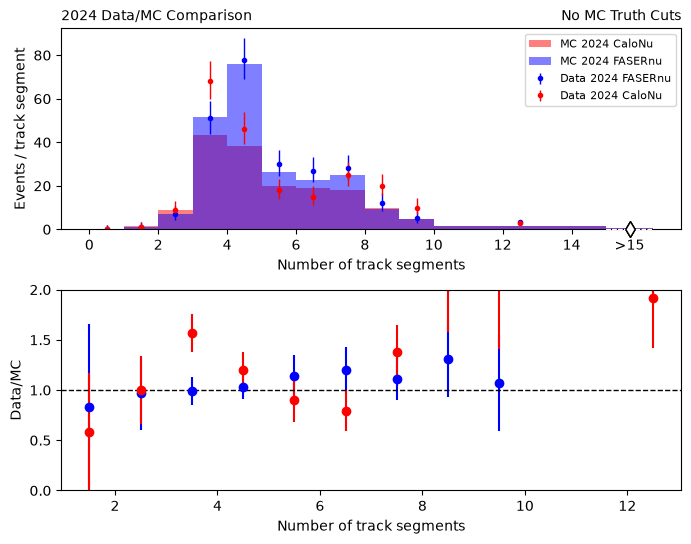

In [31]:
h_data_noCaloNu = deepcopy(h_trkseg_data_noCaloNu)
h_data_CaloNu = deepcopy(h_trkseg_data_CaloNu)

h_mc_noCaloNu = deepcopy(h_trkseg_mc_noCaloNu)
h_mc_CaloNu = deepcopy(h_trkseg_mc_CaloNu)

h_mc_noCaloNu *= lumi_2024_noCaloNu / 10_000
h_mc_CaloNu *= lumi_2024_CaloNu / 10_000

print(f"MC Scale 2024 no CaloNu: {lumi_2024_noCaloNu} / 10_000 = {lumi_2024_noCaloNu / 10_000:.2g}")
print(f"MC Scale 2024 CaloNu: {lumi_2024_CaloNu} / 10_000 = {lumi_2024_CaloNu / 10_000:.2g}")

h_noCaloNu_ratio = hist_ratio(h_data_noCaloNu, h_mc_noCaloNu)
h_CaloNu_ratio = hist_ratio(h_data_CaloNu, h_mc_CaloNu)


fig, ax = plt.subplots(figsize=(8, 6), ncols=1, nrows=2)

# ax = [ax]

hist_name = "nClusters3"

mplhep.histplot(h_data_noCaloNu, ax=ax[0], label='Data 2024 FASERnu', color='blue', histtype='errorbar', linewidth=1.5, binwnorm=True, flow='show')
mplhep.histplot(h_data_CaloNu, ax=ax[0], label='Data 2024 CaloNu', color='red', histtype='errorbar', linewidth=1.5, binwnorm=True, flow='show')

mplhep.histplot(h_mc_CaloNu, ax=ax[0], label='MC 2024 CaloNu', color='red', histtype='fill', alpha=0.5, binwnorm=True, flow='show')
mplhep.histplot(h_mc_noCaloNu, ax=ax[0], label='MC 2024 FASERnu', color='blue', histtype='fill', alpha=0.5, binwnorm=True, flow='show')

ax[0].set_title(f"2024 Data/MC Comparison", fontsize=10, loc='left')
ax[0].set_title(f"No MC Truth Cuts", fontsize=10, loc='right')
ax[0].legend(fontsize=8)
ax[0].set_xlabel("Number of track segments", fontsize=10)
ax[0].set_ylabel("Events / track segment", fontsize=10)
# ax[0].set_xscale("log")
# ax[0].set_yscale("log")
# ax[0].set_xlim(0, 1e3)

fig.subplots_adjust(hspace=0.3)

bin_centers = h_data_noCaloNu.axes[0].centers
ax[1].errorbar(bin_centers, h_noCaloNu_ratio[0], yerr=h_noCaloNu_ratio[1], fmt='o', label='Data/MC 2024 FASERnu', color='blue')
ax[1].errorbar(bin_centers, h_CaloNu_ratio[0], yerr=h_CaloNu_ratio[1], fmt='o', label='Data/MC 2024 CaloNu', color='red')
ax[1].set_xlabel("Number of track segments", fontsize=10)
ax[1].set_ylabel("Data/MC", fontsize=10)
# ax[1].set_xscale("log")
# ax[1].set_xlim(6, 1e4)
ax[1].set_ylim(0, 2)
ax[1].axhline(y=1, color='black', linestyle='--', linewidth=1)


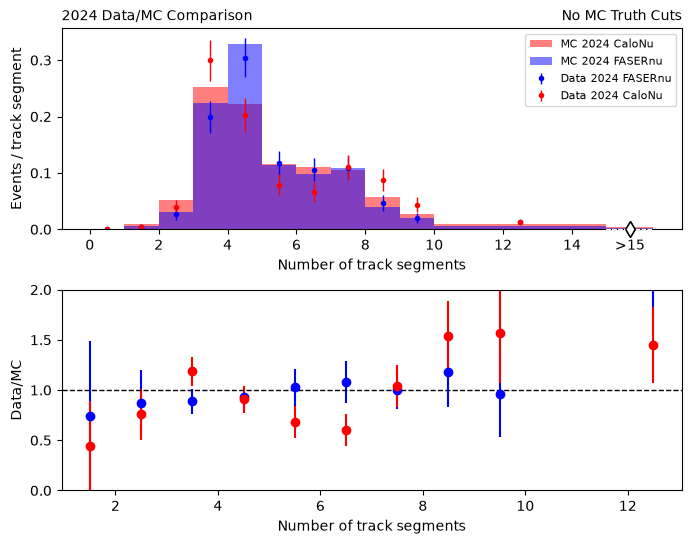

In [32]:
h_data_noCaloNu = deepcopy(h_trkseg_data_noCaloNu)
h_data_CaloNu = deepcopy(h_trkseg_data_CaloNu)

h_mc_noCaloNu = deepcopy(h_trkseg_mc_noCaloNu)
h_mc_CaloNu = deepcopy(h_trkseg_mc_CaloNu)

# Normalise data and MC to unity
h_data_noCaloNu *= 1.0 / h_data_noCaloNu.sum().value
h_data_CaloNu *= 1.0 / h_data_CaloNu.sum().value
h_mc_noCaloNu *= 1.0 / h_mc_noCaloNu.sum().value
h_mc_CaloNu *= 1.0 / h_mc_CaloNu.sum().value

h_noCaloNu_ratio = hist_ratio(h_data_noCaloNu, h_mc_noCaloNu)
h_CaloNu_ratio = hist_ratio(h_data_CaloNu, h_mc_CaloNu)


fig, ax = plt.subplots(figsize=(8, 6), ncols=1, nrows=2)

# ax = [ax]

hist_name = "nClusters3"

mplhep.histplot(h_data_noCaloNu, ax=ax[0], label='Data 2024 FASERnu', color='blue', histtype='errorbar', linewidth=1.5, binwnorm=True, flow='show')
mplhep.histplot(h_data_CaloNu, ax=ax[0], label='Data 2024 CaloNu', color='red', histtype='errorbar', linewidth=1.5, binwnorm=True, flow='show')

mplhep.histplot(h_mc_CaloNu, ax=ax[0], label='MC 2024 CaloNu', color='red', histtype='fill', alpha=0.5, binwnorm=True, flow='show')
mplhep.histplot(h_mc_noCaloNu, ax=ax[0], label='MC 2024 FASERnu', color='blue', histtype='fill', alpha=0.5, binwnorm=True, flow='show')

ax[0].set_title(f"2024 Data/MC Comparison", fontsize=10, loc='left')
ax[0].set_title(f"No MC Truth Cuts", fontsize=10, loc='right')
ax[0].legend(fontsize=8)
ax[0].set_xlabel("Number of track segments", fontsize=10)
ax[0].set_ylabel("Events / track segment", fontsize=10)
# ax[0].set_xscale("log")
# ax[0].set_yscale("log")
# ax[0].set_xlim(0, 1e3)

fig.subplots_adjust(hspace=0.3)

bin_centers = h_data_noCaloNu.axes[0].centers
ax[1].errorbar(bin_centers, h_noCaloNu_ratio[0], yerr=h_noCaloNu_ratio[1], fmt='o', label='Data/MC 2024 FASERnu', color='blue')
ax[1].errorbar(bin_centers, h_CaloNu_ratio[0], yerr=h_CaloNu_ratio[1], fmt='o', label='Data/MC 2024 CaloNu', color='red')
ax[1].set_xlabel("Number of track segments", fontsize=10)
ax[1].set_ylabel("Data/MC", fontsize=10)
# ax[1].set_xscale("log")
# ax[1].set_xlim(6, 1e4)
ax[1].set_ylim(0, 2)
ax[1].axhline(y=1, color='black', linestyle='--', linewidth=1)
